# Load Tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Import Clean Dataset

In [2]:
df = pd.read_csv('datasets/ResumeDataSet.csv')
clean_df = pd.read_csv('datasets/clean_resume_data.csv')
resume = pd.read_csv('datasets/Resume.csv')

In [3]:
clean_df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [4]:
clean_df.shape

(2484, 3)

# Exploratory Data analysis

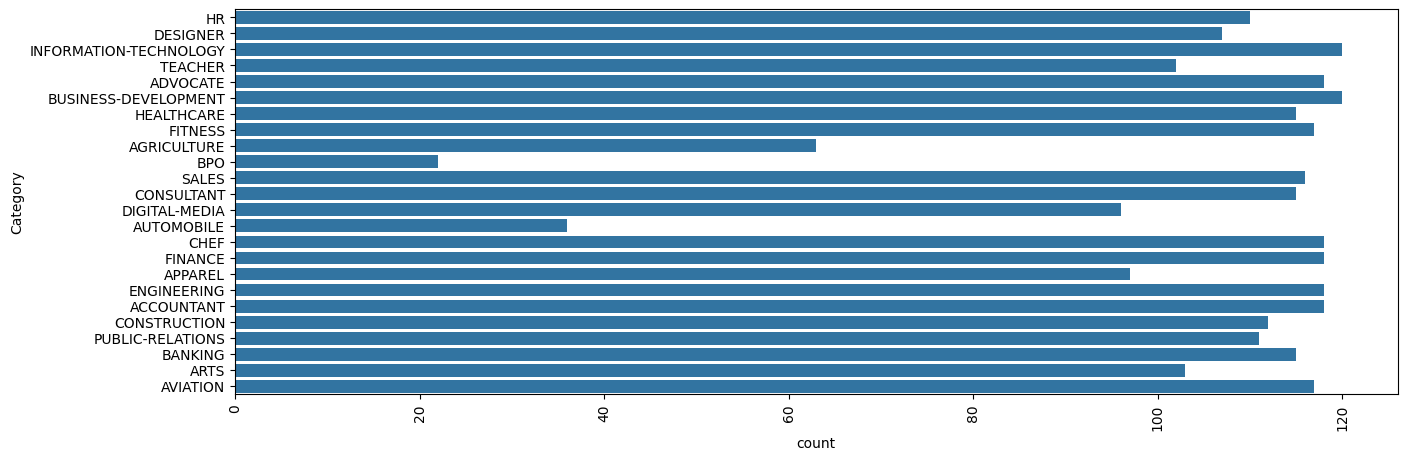

In [5]:
plt.figure(figsize=(15,5))
sns.countplot(clean_df['Category'])
plt.xticks(rotation=90)
plt.show()

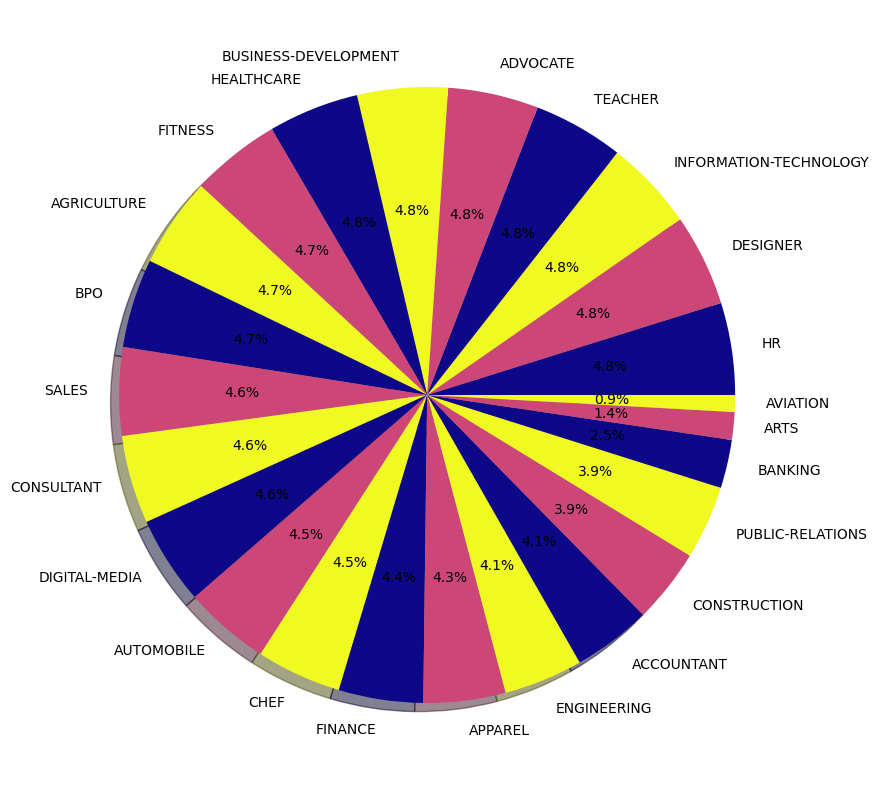

In [6]:
counts = clean_df['Category'].value_counts()
labels = clean_df['Category'].unique()
plt.figure(figsize=(15,10))

plt.pie(counts,labels=labels,autopct='%1.1f%%',shadow=True, colors=plt.cm.plasma(np.linspace(0,1,3)))
plt.show()

# Balance Dataset

In [7]:
from sklearn.utils import resample

# Define the maximum count among all categories
max_count = clean_df['Category'].value_counts().max()

# Resample each category to match the maximum count
balanced_data = []
for category in clean_df['Category'].unique():
    category_data = clean_df[clean_df['Category'] == category]
    if len(category_data) < max_count:
        # Perform oversampling for categories with fewer samples
        balanced_category_data = resample(category_data, replace=True, n_samples=max_count, random_state=42)
    else:
        # Perform undersampling for categories with more samples
        balanced_category_data = resample(category_data, replace=False, n_samples=max_count, random_state=42)
    balanced_data.append(balanced_category_data)

# Concatenate the balanced data for all categories
balanced_df = pd.concat(balanced_data)

In [8]:
# balanced_df.isnull().sum()
balanced_df.dropna(inplace=True)

# Train-Test Split


In [9]:
X = balanced_df['Feature']
y = balanced_df['Category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encoding (TF-IDF)

In [10]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

#  Train Random Forest Classifier

Accuracy: 0.8368055555555556
                        precision    recall  f1-score   support

            ACCOUNTANT       0.83      0.95      0.89        21
              ADVOCATE       1.00      0.76      0.86        29
           AGRICULTURE       0.94      0.74      0.83        23
               APPAREL       1.00      0.86      0.92        21
                  ARTS       0.93      0.64      0.76        22
            AUTOMOBILE       0.95      1.00      0.97        19
              AVIATION       0.90      0.93      0.92        30
               BANKING       1.00      0.70      0.82        23
                   BPO       1.00      1.00      1.00        15
  BUSINESS-DEVELOPMENT       0.42      0.56      0.48        18
                  CHEF       0.96      0.96      0.96        28
          CONSTRUCTION       0.93      1.00      0.96        25
            CONSULTANT       0.86      0.58      0.69        31
              DESIGNER       0.96      0.89      0.93        28
         D

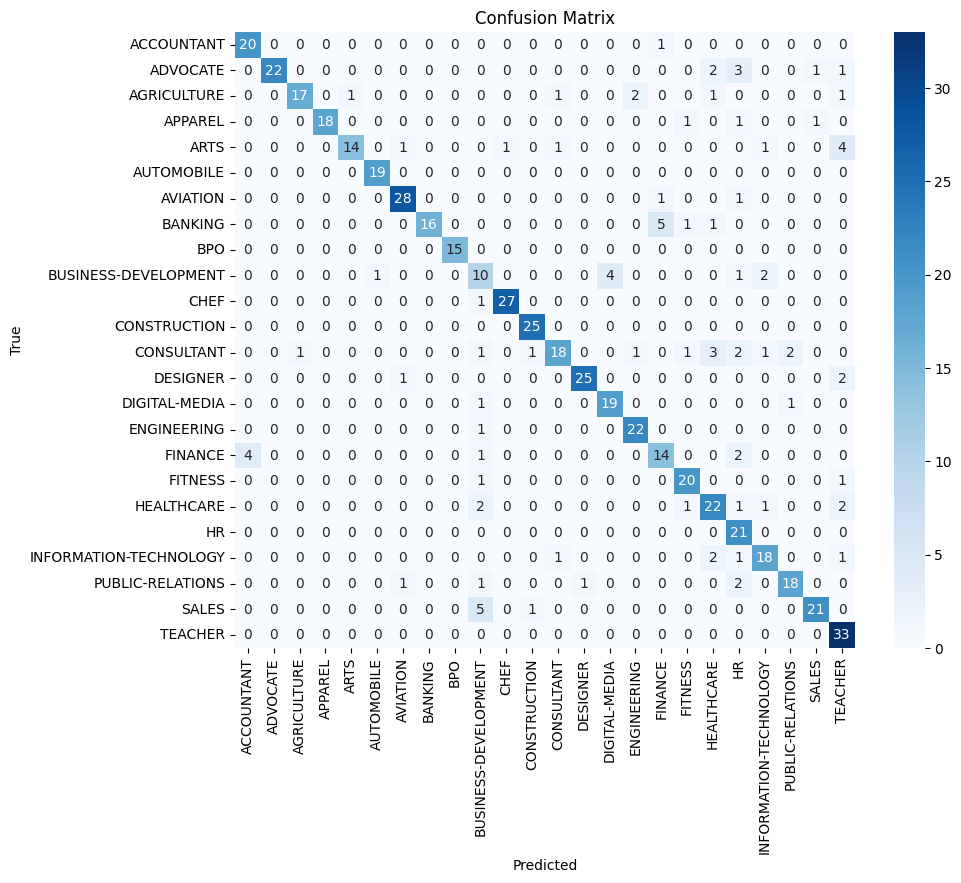

In [11]:
from sklearn.metrics import classification_report

rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train_tfidf, y_train)

# Step 4: Accuracy Evaluation
y_pred = rf_classifier.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test,y_pred))
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Predictive System

In [12]:
# Clean resume
import re
def cleanResume(txt):
    cleanText = re.sub('http\S+\s', ' ', txt)
    cleanText = re.sub('RT|cc', ' ', cleanText)
    cleanText = re.sub('#\S+\s', ' ', cleanText)
    cleanText = re.sub('@\S+', '  ', cleanText)  
    cleanText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText) 
    cleanText = re.sub('\s+', ' ', cleanText)
    return cleanText


# Prediction and Category Name
def predict_category(resume_text):
    resume_text= cleanResume(resume_text)
    resume_tfidf = tfidf_vectorizer.transform([resume_text])
    predicted_category = rf_classifier.predict(resume_tfidf)[0]
    return predicted_category

<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\]'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\S'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\]'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/var/folders/9s/jbdnt8nd4w18bf49ptkp0q4c0000gn/T/ipykernel_44413/1142954483.py:4: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('http\S+\s', ' ', txt)
/var/folders/9s/jbdnt8nd4w18bf49ptkp0q4c0000gn/T/ipykernel_44413/1142954483.py:6: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('#\S+\s', ' ', cleanText)
/var/folders/9s/jbdnt8nd4w18bf49ptkp0q4c0000gn/T/ipykernel_44413/1142954483.py:7: SyntaxWarning: invalid escape sequence '\S'
  cleanText = re.sub('@\S+', 

In [13]:
# Example Usage
resume_file = """hr assistant summary hard worker dedicated detailed oriented experienced organized highly motivated many attributes possess individual years experience human resource administration customer service talent quickly adapt new challenges experience focused benefits administration payroll career development employment law highlights assigned administrative assignments daily basis implemented employee handbook processed documentation employees conducted employees performance reviews managed employee scheduling coordinated upper level co worker lower level teamwork oriented processed new recruits processed payroll performed check managed inventory supplies secured new wholesale food purveyor decrease costs increase profits accomplishments accomplishments pho n restaurant managed restaurant financial objectives developing financing establishing banking relationships prepared strategic annual forecasts budgets analyzing variances initiating corrective actions establishing financial controls developed implemented strategies increase average meal checks created restaurant business plan surveying restaurant demand conferring people community identifying evaluating competitors preparing financial marketing sales projections analyses estimates controlled purchases inventory meeting account manager negotiating prices contracts developing preferred supplier lists reviewing evaluating usage reports analyzing variances taking corrective actions contributed team effort inspired team members motivation provided high level customer service maintain high profile day day operations handled complaints contentious issues settled directly team members provides fast solution accomplished campaign recycle program divide right trash right bin accomplishments dr norman g mckoy associates demonstrated success administrative employee handbook developing team building programs corporate policies job descriptions management reports organized office documents patients charts organized office woking areas welcomed new employees organization conducting orientation organized employees document pockets maintained employees confidence protect operation keeping human resource information confidential maintained employee information entering updating employment status change data provided payroll information collecting time attendance records provided secretarial support entering formatting printing information organizing work answering telephone relaying messages maintaining equipment supplies experience company name city state hr assistant increased productivity physician office organizing patients charts converting digital files streamline patient maintenance processed pay roll paychex includes ensured vacation sick time tracked system answered payroll questions facilited resolutions payroll errors processed incoming mails going mails successfully edited employee handbook define job descriptions create office policies patient managing proper patient reports wrote employee handbook covering issues including disciplinary procedures code conduct fmla policy benefits information wrote standard operations procedures manual sops detailed aspect employee expectations designed implement overall recruiting strategy coordinated office manager recruit right candidates administering interviews conducting background checks processed documentation prepared reports relating personnel activities staffing recruitment training performance evaluations etc identified reduced business expenses increase profits controlling budget compares actual results budget expectations company name city state general manager current hostess waitress promoted interview recruit new hires order sustain longer hours operation thus increased company profitswas successful ensuring successful integration new hires implementing training compensation structures ordered foods supplies restaurant checked maintained inventory handling daily accounting processing payroll processed cost reduction thought venders whole sale increased marketability restaurant designing creating new modernized menu prepared willing step restaurant short staff low turn order increase productivity provide best service maintained great quality quantity foods restaurant created recycle program divided recyclable bin non recyclable waste bin education bachelor arts humanities english university thai chamber commerce city thailand humanities english excelled language culture transportation management critical reading article writing advanced technical reading master science human resource management strayer university city state usa human resource management magna cum laude excelled human resources law management ethical hr information systems hris strategic management registered professional human resources aphr certification hr designations registering aphr professional human resources exam expect complete aphr certification professional affiliations enrolling ongoing training areas compensation benefits employee labor relations leaves absence workers compensation workplace safety security member society human resource management shrm skills human resource management skills employment law hr policies procedures training development performance management employee relations mediation benefits administration orientation boarding organizational development staff life cycle computer skills hris applications peoplesoft enterprise human resources ms office word excel powerpoint access outlook e mailing tools ms outlook windows outlook yahoo google networking skills job boards networking sites soft skills professional communication skills interpersonal skills bilingual thai english excellent adaptability new environments hard working flexible reliable honest polite shape decision making excellent customer service skills creative
"""

predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)

Predicted Category: HR


In [14]:
# Example Usage
resume_file='information technology manager network engineer professional overview highly skilled accomplished information technology manager years expertise planning implementing streamlining systems ensure maximum customer satisfaction business revenue strong leader demonstrated ability work effectively individuals levels functional areas exceptional communication project management skills ability successfully manage multiple priorities assignments skills platforms windows server professional windows xp pro home win dos citrix ica ms exchange hardware hp ibm dell intel based server desktop platforms cisco switches sonic wall hardware vpns hp laser jets toshiba e color copier toshiba sony laptops inter tel software ms office visio citrix metaframe xp symantec pc anywhere ghost antivirus utilities win fax mcafee virus scan adobe acrobat illustrator photoshop partition magic adware spyware networking tcp ip wireless b g dns wins dhcp relevant experience information technology manager network engineer feb current company name city state responsible day day operations functions wilkes six offices staff members currently lead team professionals developers planning upgrades implementation systems business applications development new software tools work closely cio senior management ensure business technology objectives aligned researched new technologies calculated future needs achieve accurate capacity planning negotiated hardware software purchases maintenance contracts dramatically reduced costs maintenance virtualizing company infrastructure using vmware reduced physical servers streamlined disaster recovery processes planned executed active directory domain migration r coordinated planning migration mpls network sites including upgrades routers switches network equipment increased speed reliability company email migrating microsoft exchange streamlined operations designing new citrix infrastructure using netscaler load balancers ensure better speed connectivity less downtime remote offices led planning implementation disaster recovery site atlanta created company first comprehensive business continuity plan tested success installed configuring barracuda spam virus firewalls resulting reduction spam enforced security policies managed monitored updated spam filtering virus malware prevention systems reduced desktop application deployment times designing implementing microsoft system center configuration manager conducted training internal systems local procedures technical subjects company employees coordinate external technology vendors internal staff members third party consultants network engineer sep jan company name city state administered managed windows server network environment responsible lan wan duties local remote networks acted technical consultant clients various projects provide end user support windows xp operating systems installed implemented exchange mail server implemented server desktop security using mcafee enterprise epolicy orchestrator installed configured web servers ftp servers pop mail servers manage cisco switches routers configured vpn remote access users implemented software domain policies patches upgrades using group policy sus trained new employees systems administration web development network support technician jan aug company name city provided network desktop support users provided technical support offices b domain supported help desk using help star software troubleshooting windows desktop computers implemented group policy objects control desktop environment security performed hardware software upgrades replacements performed installations troubleshooting ms office suite managed users computers organizational units active directory created disc images desktop notebook computers using norton ghost troubleshooting repairs laser printers copy machines education bachelor science management information systems university maryland university college city state certifications microsoft certified technology specialist mcts citrix certified administrator cca information systems management certificate project management certificate'

predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)

Predicted Category: INFORMATION-TECHNOLOGY


In [18]:
# Example Usage
resume_file = """Objective:
Dedicated and driven legal professional with a passion for advocating for justice and defending the rights of clients. Seeking a challenging position as an Advocate in a reputable law firm where I can apply my expertise in litigation, negotiation, and legal research to provide effective representation and achieve favorable outcomes for clients. Committed to upholding the principles of integrity, professionalism, and ethical conduct in all legal proceedings.

Education:
- Juris Doctor (JD), Law School, XYZ University
- Bachelor of Arts in Political Science, ABC College, GPA: 3.7/4.0
- Licensed Attorney, State Bar Association

Skills:
- Extensive experience in civil and criminal litigation, representing clients in court hearings, trials, and appellate proceedings
- Strong research and analytical skills, conducting legal research, drafting legal documents, and preparing persuasive arguments
- Excellent oral and written communication skills, articulating legal concepts and arguments effectively to judges, juries, and opposing counsel
- Proven track record of negotiating favorable settlements and agreements on behalf of clients, resolving disputes through mediation and arbitration
- Ability to work collaboratively with clients, colleagues, and experts to develop comprehensive legal strategies and achieve successful outcomes

Experience:
Associate Attorney | Law Firm LLP
- Handled a diverse caseload of civil and criminal matters, including personal injury, family law, employment law, and criminal defense
- Conducted legal research, drafted pleadings, motions, briefs, and other legal documents, and prepared for court hearings and trials
- Represented clients in negotiations, mediations, and settlement conferences, securing favorable outcomes and settlements
- Assisted senior attorneys in trial preparation, witness preparation, and courtroom presentations, contributing to successful trial outcomes

Legal Intern | Public Defender's Office
- Assisted attorneys in the defense of indigent clients in criminal cases, conducting legal research, drafting motions, and preparing for court appearances
- Interviewed clients, witnesses, and law enforcement officers, gathering evidence and information to support defense strategies
- Observed courtroom proceedings, including arraignments, hearings, and trials, and assisted in trial preparation and case management
- Participated in client counseling sessions, explaining legal rights, options, and potential outcomes to clients facing criminal charges

Law Clerk | Legal Aid Organization
- Provided legal assistance to low-income individuals and families in civil matters, such as landlord-tenant disputes, consumer rights, and family law matters
- Conducted intake interviews, assessed clients' legal needs, and provided information about available legal services and resources
- Drafted legal documents, including pleadings, petitions, and correspondence, and assisted clients in completing court forms and applications
- Collaborated with attorneys and social workers to address clients' legal and non-legal needs, connecting them with community resources and support services

Certifications:
- Certified Mediator, State Bar Association
- Trial Advocacy Certificate, Law School

Languages:
- English (Native)
- Spanish (Proficient)
"""
predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)

Predicted Category: ADVOCATE


In [19]:
# Example Usage
resume_file = """Objective:
Compassionate and dedicated healthcare professional with a strong background in nursing and patient care. Seeking a position as a Registered Nurse (RN) in a reputable healthcare facility where I can utilize my clinical expertise, critical thinking skills, and passion for improving patient outcomes. Eager to contribute to a multidisciplinary team and make a positive impact on the lives of patients.

Education:
- Bachelor of Science in Nursing (BSN), XYZ University, GPA: 3.9/4.0
- Registered Nurse (RN) License, State Board of Nursing
- Basic Life Support (BLS) and Advanced Cardiovascular Life Support (ACLS) Certification

Skills:
- Proficient in conducting comprehensive patient assessments, developing care plans, and administering medications and treatments according to physician orders
- Strong clinical skills in various healthcare settings, including medical-surgical units, emergency departments, and intensive care units
- Excellent interpersonal and communication skills, collaborating with healthcare team members, patients, and families to ensure coordinated and effective care
- Ability to prioritize tasks, manage time efficiently, and adapt to fast-paced and high-pressure environments
- Commitment to upholding ethical standards, maintaining patient confidentiality, and providing culturally sensitive care

Experience:
Registered Nurse (RN) | ABC Hospital
- Provided direct patient care to medical-surgical patients, assessing vital signs, monitoring symptoms, and administering medications and treatments
- Collaborated with physicians and other healthcare professionals to develop and implement individualized care plans, ensuring optimal patient outcomes
- Educated patients and families about medical conditions, treatment options, and self-care techniques, empowering them to actively participate in their healthcare
- Maintained accurate and detailed patient records, documenting assessments, interventions, and outcomes in electronic medical records (EMR) systems

Clinical Nurse | XYZ Clinic
- Assisted in the management of a busy outpatient clinic, triaging patients, performing procedures, and providing patient education and counseling
- Conducted health screenings, immunizations, and diagnostic tests, interpreting results and communicating findings to patients and healthcare providers
- Participated in quality improvement initiatives and clinical research projects to enhance patient care practices and outcomes
- Facilitated group education sessions on topics such as diabetes management, hypertension control, and smoking cessation

Nursing Intern | Community Hospital
- Rotated through various departments, including medical-surgical, emergency, and maternal-child health units, gaining exposure to diverse patient populations and healthcare settings
- Assisted nursing staff with patient care activities, such as bathing, dressing, feeding, and ambulating patients, ensuring their comfort and safety
- Observed and participated in nursing procedures, treatments, and patient assessments under the supervision of experienced nurses
- Attended educational seminars and workshops to expand clinical knowledge and skills in nursing practice

Certifications:
- Basic Life Support (BLS) Certification
- Advanced Cardiovascular Life Support (ACLS) Certification
- Pediatric Advanced Life Support (PALS) Certification

Languages:
- English (Native)
- Spanish (Proficient)

"""
predicted_category = predict_category(resume_file)
print("Predicted Category:", predicted_category)

Predicted Category: HEALTHCARE


# Save Files

In [20]:
import pickle
pickle.dump(rf_classifier,open('models/rf_classifier_categorization.pkl','wb'))
pickle.dump(tfidf_vectorizer,open('models/tfidf_vectorizer_categorization.pkl','wb'))